# University Rankings Data Cleaning

This notebook cleans `university_raw_data.csv` (22,145 rows × 38 columns of QS-style
world-university-ranking data). It walks through:

1. Initial inspection
2. Removing duplicate rows
3. Standardizing text/categorical fields (whitespace, casing, country names)
4. Fixing corrupted/out-of-range numeric fields
5. Fixing data types
6. Handling missing values
7. Final validation and export

**Before running:** put `university_raw_data.csv` in the same folder as this notebook,
or update `RAW_PATH` below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

RAW_PATH = "university_raw_data.csv"
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()

Shape: (22145, 38)


,university_id,year,university_name,world_rank,national_rank,overall_score,country,region,city,university_type,academic_reputation_score,employer_reputation_score,citations_score,publications_count,citations_count,citations_per_faculty,h_index,research_output_score,research_productivity_index,subject_field,total_students,international_students_count,international_student_ratio,faculty_count,faculty_to_student_ratio,gender_ratio,female_percentage,male_percentage,degree_level,undergraduate_count,postgraduate_count,country_avg_rank,universities_ranked_count,best_university_rank,country_avg_overall_score,country_avg_academic_reputation,country_avg_citations,country_avg_international_ratio
0,1534,2018,Pontificia Universidad Católica Argentina,364.0,4.0,33.0000,Argentina,Latin America,Buenos Aires,PRIVATE,28.818098,33.421067,33.126557,14526,105384,27.696184,315,31.0,3.82,Social Sciences & Management,15220.0,1063.0,6.984231,3805.0,4.000000,34 : 66,33.991545,66.008455,UNDERGRADUATE & POSTGRADUATE,9560,5660,652.65,17,75.0,33.63,33.37,34.59,83.01
1,1269,2023,National Chi Nan University,1642.0,42.0,15.7275,TAIWAN,Asia,Taiwan,Private,16.417597,17.961854,19.830751,1590,4996,12.776372,72,18.1,4.07,Natural Sciences,5773.0,635.0,11.000000,391.0,14.764706,54:46:00,54.000000,46.000000,Undergraduate & Postgraduate,3452,2321,1041.45,47,77.0,26.27,20.02,19.55,8.87
2,299,2026,Canterbury Christ Church University,1300.5,113.0,29.4325,United Kingdom,Europe,Bexleyheath,Public,6.800000,4.700000,6.800000,3852,9099,6.800609,90,6.8,2.88,Arts & Humanities,23395.0,12867.0,55.000000,1338.0,17.485052,57:43:00,57.000000,43.000000,Undergraduate & Postgraduate,15183,8212,614.48,126,2.0,46.87,35.82,38.92,35.29
3,600,2023,Gazi University,1226.0,28.0,23.7450,TURKEY,Asia,Turkey,Private,22.232035,24.424246,30.888541,6785,110404,36.678974,390,26.6,2.25,Arts & Humanities,41358.0,1241.0,3.000000,3010.0,13.740199,50:50:00,50.000000,50.000000,Undergraduate & Postgraduate,28683,12675,1264.96,73,460.0,24.69,17.31,16.31,8.88
4,2878,2016,University of Oulu,399.0,6.0,35.4300,Finland,Europe,Oulu,Public,43.577886,37.343540,38.804667,2934,15643,22.671226,137,41.2,4.25,Arts & Humanities,14056.0,843.0,6.000000,690.0,20.371014,49:51:00,49.000000,51.000000,Undergraduate & Postgraduate,9480,4576,352.89,9,76.0,38.96,38.59,40.11,9.00


## 1. Initial inspection

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22145 entries, 0 to 22144
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   university_id                    22145 non-null  int64  
 1   year                             22145 non-null  int64  
 2   university_name                  22145 non-null  str    
 3   world_rank                       21674 non-null  float64
 4   national_rank                    21891 non-null  float64
 5   overall_score                    22145 non-null  float64
 6   country                          22145 non-null  str    
 7   region                           22145 non-null  str    
 8   city                             22145 non-null  str    
 9   university_type                  22145 non-null  str    
 10  academic_reputation_score        22145 non-null  float64
 11  employer_reputation_score        21923 non-null  float64
 12  citations_score              

world_rank                     471
national_rank                  254
employer_reputation_score      222
subject_field                  222
international_student_ratio    221
faculty_count                  221
country_avg_rank                 2
best_university_rank             2
dtype: int64


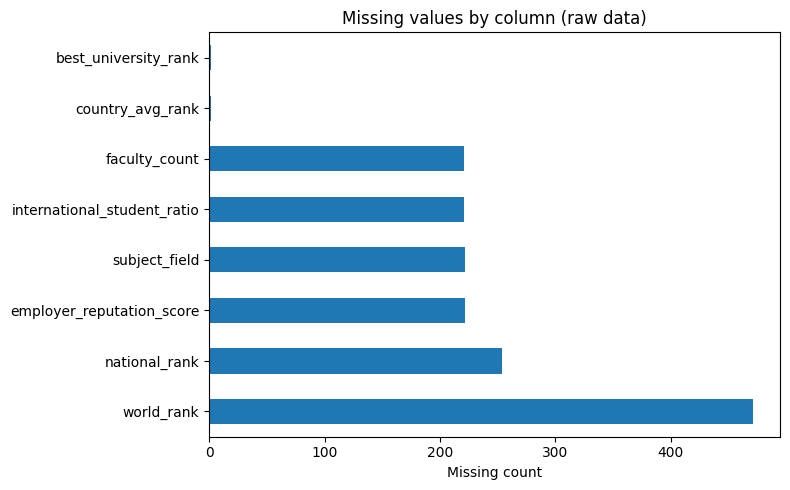

In [3]:
# Missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(8, 5))
missing.plot(kind='barh')
plt.title("Missing values by column (raw data)")
plt.xlabel("Missing count")
plt.tight_layout()
plt.show()

In [4]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 20


In [5]:
# A quick look at how messy the categorical columns are (whitespace + inconsistent casing)
print(df['country'].unique()[:15])
print()
print(df['university_type'].unique())

<StringArray>
[     'Argentina',       'TAIWAN  ', 'United Kingdom',         'TURKEY',        'Finland',      'Germany  ',     'bangladesh',       ' Japan  ',
           'Iran',      'Indonesia',         'jordan',         'Mexico',          'India',        'Germany',         ' JAPAN']
Length: 15, dtype: str

<StringArray>
[                  'PRIVATE',                 'Private  ',                   ' Public',                   'Private',                 ' Public  ',
                   'private',                    'Public',                  'Public  ',                    'PUBLIC',    'Private not for Profit',
                 'private  ',                    'public',                 'PRIVATE  ',                  ' Private',        'Private for Profit',
                   ' public',                        ' C',                  'public  ',                  ' private',                ' Private  ',
                         'C',                   ' PUBLIC',                  'PUBLIC  ',  'Pr

## 2. Remove exact duplicate rows

Some rows are byte-for-byte duplicates and can simply be dropped.

In [6]:
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows")
print("New shape:", df.shape)

Dropped 20 exact duplicate rows
New shape: (22125, 38)


## 3. Clean text columns

Trim whitespace and standardize casing. `university_name` and `city` are kept as
free text (only trimmed); the "controlled vocabulary" columns
(`country`, `region`, `university_type`, `subject_field`, `degree_level`) are
title-cased so that e.g. `" JAPAN"`, `"japan"`, and `"Japan  "` all collapse to `"Japan"`.

In [7]:
text_cols = ["university_name", "country", "region", "city",
             "university_type", "subject_field", "degree_level"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"nan": np.nan})

cat_cols = ["country", "region", "university_type", "subject_field", "degree_level", "city"]
for col in cat_cols:
    df[col] = df[col].str.title()

print("Unique countries (raw variants collapsed by casing/whitespace):", df['country'].nunique())
print("Regions:", sorted(df['region'].dropna().unique()))

Unique countries (raw variants collapsed by casing/whitespace): 142
Regions: ['Africa', 'Americas', 'Asia', 'Europe', 'Latin America', 'North America', 'Not Classified', 'Oceania', 'Other']


## 4. Standardize country names

After fixing case/whitespace, some countries are still recorded under multiple
names (e.g. `"China (Mainland)"` vs `"China"`, `"Türkiye"` vs `"Turkey"`,
`"Republic Of Korea"` vs `"South Korea"`). Merge these into one canonical spelling.

In [8]:
country_map = {
    "China (Mainland)": "China",
    "Czech Republic": "Czechia",
    "Hong Kong Sar": "Hong Kong",
    "Hong Kong Sar, China": "Hong Kong",
    "Iran (Islamic Republic Of)": "Iran",
    "Iran, Islamic Republic Of": "Iran",
    "Macao Sar, China": "Macao",
    "Macau Sar": "Macao",
    "Palestinian Territory, Occupied": "Palestine",
    "Republic Of Korea": "South Korea",
    "Russian Federation": "Russia",
    "Syrian Arab Republic": "Syria",
    "Türkiye": "Turkey",
    "United States Of America": "United States",
    "Venezuela (Bolivarian Republic Of)": "Venezuela",
    "Viet Nam": "Vietnam",
    "Brunei Darussalam": "Brunei",
}

df["country"] = df["country"].replace(country_map)
print("Unique countries after standardizing:", df["country"].nunique())

Unique countries after standardizing: 126


## 5. Fix `university_type`

Besides the expected `Public` / `Private` / `Private Not For Profit` /
`Private For Profit` categories, there's a stray `"C"` value (135 rows) that
isn't a valid category — most likely a truncated/corrupted entry. Since we can't
reliably guess what it should be, it's set to missing rather than left as junk.

In [9]:
valid_types = {"Public", "Private", "Private Not For Profit", "Private For Profit"}
invalid_type_mask = ~df["university_type"].isin(valid_types)
print("Rows with invalid university_type set to NaN:", invalid_type_mask.sum())

df.loc[invalid_type_mask, "university_type"] = np.nan
df["university_type"].value_counts(dropna=False)

Rows with invalid university_type set to NaN: 135


university_type
Public                    16641
Private                    4967
Private Not For Profit      324
NaN                         135
Private For Profit           58
Name: count, dtype: int64

## 6. Fix `city`

In ~44% of rows, `city` is literally the same as `country` (e.g. city = "Japan").
This looks like a placeholder used when the real city wasn't captured, not an
actual city name, so it's treated as missing.

In [10]:
mask_city_is_country = df["city"].str.lower() == df["country"].str.lower()
print("City cleared (was same as country):", mask_city_is_country.sum())

df.loc[mask_city_is_country, "city"] = np.nan

City cleared (was same as country): 9709


## 7. Rebuild `gender_ratio`

`gender_ratio` shows up in several inconsistent formats (`"34 : 66"`,
`"54:46:00"`, `" 49:51:00"`, etc.), while the numeric `female_percentage` /
`male_percentage` columns already carry the same information reliably.
Rebuild `gender_ratio` from those two columns into one clean `"F:M"` format.

In [11]:
df["gender_ratio"] = (
    df["female_percentage"].round(0).astype("Int64").astype(str)
    + ":" +
    df["male_percentage"].round(0).astype("Int64").astype(str)
)
df["gender_ratio"].head()

0    34:66
1    54:46
2    57:43
3    50:50
4    49:51
Name: gender_ratio, dtype: str

## 8. Fix corrupted numeric columns

Three related columns show clear signs of corruption in a subset of rows:

- **`international_students_count`**: ~2,000 rows hold small decimal values
  (e.g. `4.77`, `1.415`) that can't be real headcounts.
- **`international_student_ratio`**: should be a 0–100 percentage, but some
  rows go up to 12,523.
- **`faculty_count`**: exactly `50` for the same rows as the corrupted
  student counts — almost certainly a placeholder rather than a real value.

Rather than guess a "correct" number, these are treated as missing. The ratio
is then recomputed from `international_students_count / total_students` where
both are available, which also fills some of the original gaps.

In [12]:
# international_students_count: tiny non-integer values are invalid
bad_intl_count = (df["international_students_count"] % 1 != 0) & (df["international_students_count"] < 20)
print("Invalid international_students_count rows:", bad_intl_count.sum())
df.loc[bad_intl_count, "international_students_count"] = np.nan

# international_student_ratio: must be a 0-100 percentage
bad_ratio = (df["international_student_ratio"] > 100) | (df["international_student_ratio"] < 0)
print("Invalid international_student_ratio rows:", bad_ratio.sum())
df.loc[bad_ratio, "international_student_ratio"] = np.nan

# Recompute the ratio where possible, only filling gaps (don't overwrite valid values)
recomputed_ratio = df["international_students_count"] / df["total_students"] * 100
df["international_student_ratio"] = df["international_student_ratio"].fillna(recomputed_ratio).round(2)

# faculty_count: the exact value 50 lines up with the corrupted student-count rows
bad_faculty = (df["faculty_count"] == 50) & bad_intl_count
print("Invalid faculty_count rows:", bad_faculty.sum())
df.loc[bad_faculty, "faculty_count"] = np.nan

Invalid international_students_count rows: 2052
Invalid international_student_ratio rows: 322
Invalid faculty_count rows: 1387


## 9. Fix data types

Rank/count columns were stored as floats only because of missing values.
Convert them to nullable integers (`Int64`) so they display and behave like
counts, while keeping `NaN` for genuinely missing entries.

In [13]:
int_like_cols = ["world_rank", "national_rank", "faculty_count",
                  "international_students_count", "best_university_rank"]
for col in int_like_cols:
    df[col] = df[col].round(0).astype("Int64")

df["year"] = df["year"].astype(int)
df[int_like_cols + ["year"]].dtypes

world_rank                      Int64
national_rank                   Int64
faculty_count                   Int64
international_students_count    Int64
best_university_rank            Int64
year                            int64
dtype: object

## 10. Validate score columns

All `*_score` columns are meant to be on a 0–100 scale. Clip anything outside
that range (after inspecting how many rows are actually affected).

In [14]:
score_cols = ["overall_score", "academic_reputation_score", "employer_reputation_score",
              "citations_score", "research_output_score"]
for col in score_cols:
    out_of_range = (~df[col].between(0, 100)) & df[col].notna()
    print(f"{col}: {out_of_range.sum()} out-of-range values")
    df[col] = df[col].clip(0, 100)

overall_score: 0 out-of-range values
academic_reputation_score: 0 out-of-range values
employer_reputation_score: 0 out-of-range values
citations_score: 0 out-of-range values
research_output_score: 0 out-of-range values


## 11. Handle remaining missing values

- `subject_field`: fill with an explicit `"Unknown"` label rather than leaving blank,
  since it's a categorical field.
- All other missing numeric fields (`world_rank`, `national_rank`,
  `employer_reputation_score`, `faculty_count`, etc.) are left as `NaN` —
  imputing rankings or scores with guessed values would distort analysis.
  Decide per-analysis whether to drop or impute them (e.g. group median by country/year).

In [15]:
df["subject_field"] = df["subject_field"].fillna("Unknown")

remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
print(remaining_missing)

city                            9709
international_students_count    2052
faculty_count                   1608
world_rank                       468
national_rank                    252
employer_reputation_score        221
university_type                  135
international_student_ratio       27
country_avg_rank                   2
best_university_rank               2
dtype: int64


## 12. Final checks

In [16]:
# Duplicate (university, year, country) combos after standardizing names
dup_after = df.duplicated(subset=["university_name", "year", "country"]).sum()
print("Duplicate university/year/country combos remaining:", dup_after)
df[df.duplicated(subset=["university_name", "year", "country"], keep=False)].sort_values(
    ["university_name", "year"]
).head(10)

Duplicate university/year/country combos remaining: 8


,university_id,year,university_name,world_rank,national_rank,overall_score,country,region,city,university_type,academic_reputation_score,employer_reputation_score,citations_score,publications_count,citations_count,citations_per_faculty,h_index,research_output_score,research_productivity_index,subject_field,total_students,international_students_count,international_student_ratio,faculty_count,faculty_to_student_ratio,gender_ratio,female_percentage,male_percentage,degree_level,undergraduate_count,postgraduate_count,country_avg_rank,universities_ranked_count,best_university_rank,country_avg_overall_score,country_avg_academic_reputation,country_avg_citations,country_avg_international_ratio
887,1790,2022,Soochow University,1201,27,27.7,Taiwan,Asia,Taipei City,Private,32.561611,30.315603,25.392411,325,12056,16.247787,112,29.0,0.44,Engineering & Technology,15582.000,681,4.37,742,21.000000,56:44,56.351785,43.648215,Undergraduate & Postgraduate,10440,5142,964.78,43,68,25.29,26.47,24.49,7.33
888,1790,2022,Soochow University,1201,27,27.7,Taiwan,Asia,Taipei City,Private,32.561611,30.315603,25.392411,325,12056,16.247787,112,29.0,0.44,Engineering & Technology,47.034,<NA>,2.98,<NA>,13.000000,63:37,63.066792,36.933208,Undergraduate & Postgraduate,42,5,545.59,58,17,41.15,41.21,41.62,351.71
20622,1790,2022,Soochow University,626,36,62.4,China,Asia,Suzhou,Public,52.497518,54.891033,71.023852,184,3392,67.845158,55,61.8,3.68,Engineering & Technology,15582.000,681,4.37,742,21.000000,56:44,56.351785,43.648215,Undergraduate & Postgraduate,10440,5142,964.78,43,68,25.29,26.47,24.49,7.33
20623,1790,2022,Soochow University,626,36,62.4,China,Asia,Suzhou,Public,52.497518,54.891033,71.023852,184,3392,67.845158,55,61.8,3.68,Engineering & Technology,47.034,<NA>,2.98,<NA>,13.000000,63:37,63.066792,36.933208,Undergraduate & Postgraduate,42,5,545.59,58,17,41.15,41.21,41.62,351.71
8920,1790,2023,Soochow University,1279,29,28.9,Taiwan,Asia,Taipei City,Private,4.300000,7.200000,1.900000,7718,2306,1.370421,53,3.1,4.59,Life Sciences & Medicine,18595.000,3429,18.44,1683,11.048723,50:50,50.483160,49.516840,Undergraduate & Postgraduate,11156,7439,1041.45,47,77,26.27,20.02,19.55,8.87
8921,1790,2023,Soochow University,1279,29,28.9,Taiwan,Asia,Taipei City,Private,4.300000,7.200000,1.900000,7718,2306,1.370421,53,3.1,4.59,Life Sciences & Medicine,25235.000,4944,19.59,1389,18.167747,47:53,47.220734,52.779266,Undergraduate & Postgraduate,20688,4547,625.92,71,12,42.98,16.89,52.32,12.56
16531,1790,2023,Soochow University,684,43,62.0,China,Asia,Taipei City,Private,5.100000,2.300000,64.000000,6358,67605,48.671942,239,34.6,4.58,Natural Sciences,18595.000,3429,18.44,1683,11.048723,50:50,50.483160,49.516840,Undergraduate & Postgraduate,11156,7439,1041.45,47,77,26.27,20.02,19.55,8.87
16532,1790,2023,Soochow University,684,43,62.0,China,Asia,Taipei City,Private,5.100000,2.300000,64.000000,6358,67605,48.671942,239,34.6,4.58,Natural Sciences,25235.000,4944,19.59,1389,18.167747,47:53,47.220734,52.779266,Undergraduate & Postgraduate,20688,4547,625.92,71,12,42.98,16.89,52.32,12.56
8203,1790,2024,Soochow University,<NA>,<NA>,1.0,Taiwan,Asia,Taipei City,NaN,4.700000,6.000000,1.800000,1937,1274,1.172926,40,3.2,1.78,Engineering & Technology,30978.000,6836,22.07,3517,8.808075,73:27,73.327123,26.672877,Undergraduate & Postgraduate,23777,7201,635.03,71,17,40.73,17.99,56.18,13.26
8204,1790,2024,Soochow University,<NA>,<NA>,1.0,Taiwan,Asia,Taipei City,NaN,4.700000,6.000000,1.800000,1937,1274,1.172926,40,3.2,1.78,Engineering & Technology,18730.000,2222,11.86,1086,17.246777,52:48,52.177228,47.822772,Undergraduate & Postgraduate,10697,8033,1067.02,49,69,28.18,22.92,20.35,8.19


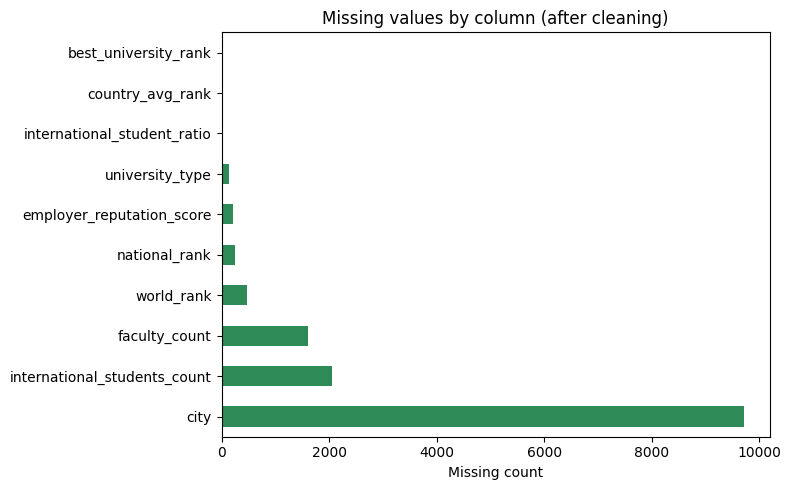

In [17]:
plt.figure(figsize=(8, 5))
remaining_missing.plot(kind='barh', color='seagreen')
plt.title("Missing values by column (after cleaning)")
plt.xlabel("Missing count")
plt.tight_layout()
plt.show()

In [18]:
print("Final shape:", df.shape)
df.describe(include='all').T.head(20)

Final shape: (22125, 38)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
university_id,22125.0,NaN,NaN,NaN,1762.041718,981.261038,1.0,924.0,1793.0,2625.0,3416.0
year,22125.0,NaN,NaN,NaN,2021.935729,2.976317,2016.0,2020.0,2022.0,2025.0,2026.0
university_name,22125,3416,Soochow University,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
world_rank,21657.0,<NA>,<NA>,<NA>,770.854828,482.087478,1.0,381.0,726.0,1100.0,2191.0
national_rank,21873.0,<NA>,<NA>,<NA>,35.607324,43.044531,1.0,7.0,20.0,47.0,264.0
overall_score,22125.0,NaN,NaN,NaN,36.028037,16.703985,1.0,24.3,33.22,45.1,100.0
country,22125,126,United States,2547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,22125,9,Europe,7827,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,12416,867,Russian Federation,316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
university_type,21990,4,Public,16641,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 13. Save cleaned data

In [19]:
OUT_PATH = "university_cleaned.csv"
df.to_csv(OUT_PATH, index=False)
print(f"Saved cleaned dataset to {OUT_PATH}  |  shape={df.shape}")

Saved cleaned dataset to university_cleaned.csv  |  shape=(22125, 38)


## Summary of changes

| Issue | Fix |
|---|---|
| 20 exact duplicate rows | Dropped |
| Inconsistent whitespace/casing in text columns | Trimmed + title-cased |
| Country recorded under multiple spellings (e.g. `China (Mainland)`) | Consolidated via mapping |
| Invalid `university_type` value `"C"` | Set to missing |
| `city` filled with the country name as a placeholder | Set to missing |
| `gender_ratio` in inconsistent formats | Rebuilt from `female_percentage`/`male_percentage` |
| Corrupted tiny decimals in `international_students_count` | Set to missing |
| `international_student_ratio` > 100% | Set to missing, recomputed where possible |
| Placeholder `faculty_count == 50` on corrupted rows | Set to missing |
| Float dtypes on count/rank columns | Converted to nullable `Int64` |
| Scores outside 0–100 | Clipped |
| Missing `subject_field` | Labeled `"Unknown"` |

Remaining `NaN`s (ranks, scores, faculty counts, etc.) were left as missing on
purpose — how to treat them (drop vs. impute) should depend on the specific
analysis you're doing next.